# EDA 

>  Fuente : airbnd NY

In [16]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")


Información general del dataset

In [17]:
df.shape
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Revisar valores nulos y duplicados 

In [18]:
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

### Variables categoricas 

In [20]:
df['neighbourhood_group'].value_counts()
df['room_type'].value_counts()


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

### Variables numericas 

In [21]:
df['price'].describe()
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

### Visualizar distribuciones 

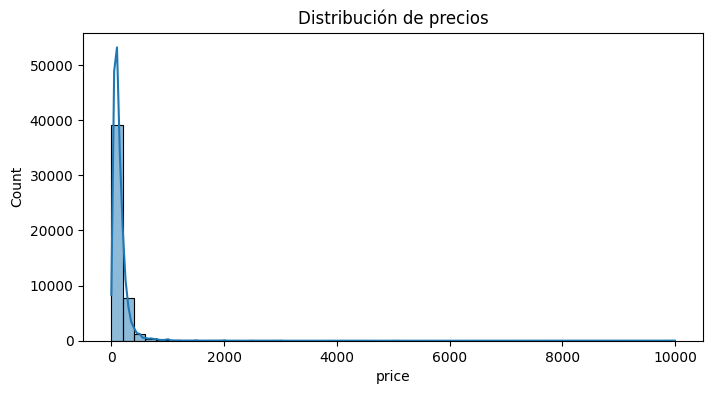

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribución de precios')
plt.show()

#### RELACIONES 

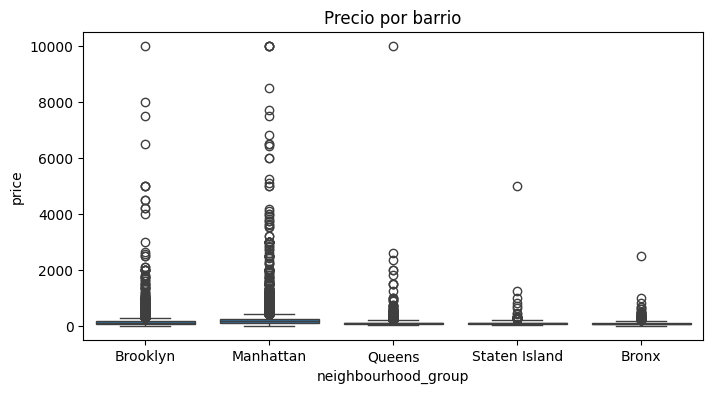

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title('Precio por barrio')
plt.show()

Division del conjunto de datos en train y test

In [26]:
 # Eliminar columnas irrelevantes
cols_to_drop = ['id', 'name', 'host_name', 'last_review']
X = df.drop(cols_to_drop + ['price'], axis=1)

# Convertir variables categóricas a dummies
X = pd.get_dummies(X, drop_first=True)

y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Primeras filas de X_train:")
print(X_train.head())
print("Primeras filas de y_train:")
print(y_train.head())

Shape de X_train: (39116, 234)
Shape de X_test: (9779, 234)
Primeras filas de X_train:
        host_id  latitude  longitude  minimum_nights  number_of_reviews  \
32645   9038810  40.71577  -73.95530               3                 11   
23615  81745867  40.84917  -73.94048               2                  2   
31183   1218837  40.68993  -73.95947               2                  0   
29260   4126686  40.68427  -73.93118               3                 87   
7275   27698133  40.74705  -73.89564               5                 13   

       reviews_per_month  calculated_host_listings_count  availability_365  \
32645               0.87                               1                 1   
23615               0.16                               1                 0   
31183                NaN                               2                 0   
29260               4.91                               1               267   
7275                0.25                               1                

### Conclusion 



El archivo tiene información de alojamientos en Nueva York, como precios, barrios y tipo de habitación.

Encontramos algunos datos vacíos (como en la columna de reseñas), pero no son muchos y se pueden quitar o completar.

No hay muchos datos repetidos, así que la calidad de los datos es buena.

La columna del precio tiene valores muy altos en pocos casos, pero la mayoría son precios bajos.

El tipo de barrio y el tipo de habitación influyen mucho en el precio, por eso son importantes para predecirlo.

Preparamos bien los datos: quitamos columnas que no sirven y convertimos las categorías (como el tipo de habitación) en números.

También dividimos el archivo en datos para entrenar un modelo y datos para probarlo después.

En resumen:
Este análisis nos ayudó a entender los datos y prepararlos bien para poder hacer predicciones sobre los precios de Airbnb en Nueva York.